# EDA — EEG por Estímulo Páginas Web

In [6]:
import ray, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = ("/Volumes/Externo4T/GoogleDrive/Tesistas Neurodatos/"
        "Datos  Crudos/EEG/EEG por Estímulo/Estímulos Páginas web")
FS         = 125
SAT_THRESH = 90_000

ray.init("ray://localhost:10001")
print(ray.cluster_resources())

2026-07-04 17:48:27,881	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver


RuntimeError: Ray Client is already connected. Maybe you called ray.init("ray://<address>") twice by accident?

In [7]:
@ray.remote
def listar(ruta):
    import os, re
    return sorted(f for f in os.listdir(ruta)
                  if re.match(r"P\d+_Estimulo_\d+\.csv", f))

@ray.remote
def procesar(ruta, nombre, sat_thresh, fs):
    """
    Pipeline por archivo:
      1. Leer sin header, asignar nombres por posición
      2. Botar fila 0 (todos los canales en ±187500 — ringing si se filtra)
      3. Marcar canales saturados (no se filtran)
      4. Band-pass 1–45 Hz con filtfilt (zero-phase, sin desfase)
      5. Stats + PSD sobre señal limpia
    """
    import os, re, numpy as np, pandas as pd
    from scipy.signal import butter, filtfilt

    path = os.path.join(ruta, nombre)
    m    = re.match(r"P(\d+)_Estimulo_(\d+)\.csv", nombre)
    pid, est = int(m.group(1)), int(m.group(2))

    def bp(sig, fs, lo=1.0, hi=45.0, orden=4):
        nyq = fs / 2
        b, a = butter(orden, [lo / nyq, hi / nyq], btype="band")
        return filtfilt(b, a, sig)

    def welch_np(sig, fs, nperseg):
        window = np.hanning(nperseg)
        hop    = nperseg // 2
        freqs  = np.fft.rfftfreq(nperseg, d=1.0 / fs)
        scale  = fs * (window ** 2).sum()
        segs, i = [], 0
        while i + nperseg <= len(sig):
            chunk = sig[i:i + nperseg] * window
            segs.append(np.abs(np.fft.rfft(chunk)) ** 2 / scale)
            i += hop
        return freqs, np.mean(segs, axis=0) if segs else (freqs, np.zeros_like(freqs))

    try:
        with open(path, "r", errors="replace") as f:
            primera = f.readline()
        n_cols  = len(primera.strip().split(","))
        n_eeg   = min(16, n_cols - 2)
        n_extra = n_cols - 2 - n_eeg
        nombres  = (["SampleIndex"] +
                    [f"EXG Channel {i}" for i in range(n_eeg)] +
                    [f"Extra{i}" for i in range(n_extra)] +
                    ["Estimulo"])
        eeg_cols = [f"EXG Channel {i}" for i in range(n_eeg)]

        df = pd.read_csv(path, header=None, names=nombres, skipinitialspace=True)

        # — Paso 1: botar fila 0 anómala —
        df = df.iloc[1:].reset_index(drop=True)

        # — Paso 2: marcar canales saturados (ANTES de filtrar) —
        sat = {c: float((pd.to_numeric(df[c], errors="coerce").abs() > sat_thresh).mean() * 100)
               for c in eeg_cols}
        n_sat  = sum(v == 100 for v in sat.values())
        buenos = [c for c in eeg_cols if sat[c] < 50]

        # — Paso 3: band-pass 1–45 Hz zero-phase —
        min_len = fs * 4
        filtradas = {}
        for c in buenos:
            raw = pd.to_numeric(df[c], errors="coerce").fillna(0).values.astype(float)
            filtradas[c] = bp(raw, fs) if len(raw) >= min_len else raw

        mean_amp = float(np.mean([s.mean() for s in filtradas.values()])) if filtradas else float("nan")

        # — Paso 4: PSD sobre señal filtrada —
        nperseg = fs * 4
        psds, f_arr = [], None
        for c, sig in filtradas.items():
            if len(sig) >= nperseg:
                f_arr, p = welch_np(sig, fs, nperseg)
                psds.append(p)

        return {
            "participante": pid, "estimulo": est,
            "n_muestras": len(df), "duracion_s": len(df) / fs,
            "n_sat_ch": n_sat, "mean_amp": mean_amp,
            "freqs": f_arr.tolist() if psds else None,
            "psd":   np.mean(psds, axis=0).tolist() if psds else None,
        }
    except Exception as e:
        return {"participante": pid, "estimulo": est, "error": str(e)}

In [8]:
from ray.util.scheduling_strategies import NodeAffinitySchedulingStrategy

@ray.remote
def check_nodo(ruta):
    import os, ray
    return {
        "node_id": ray.get_runtime_context().get_node_id(),
        "tiene_disco": os.path.exists(ruta),
    }

recursos = ray.cluster_resources()
ips = [k.split("node:")[1] for k in recursos
       if k.startswith("node:") and "__internal_head__" not in k]
print("Nodos en el cluster:", ips)

checks = ray.get([
    check_nodo.options(resources={f"node:{ip}": 0.001}).remote(RUTA)
    for ip in ips
])
for ip, c in zip(ips, checks):
    print(f"  {ip} → disco: {c['tiene_disco']}")

nodo_disco = next((c["node_id"] for c in checks if c["tiene_disco"]), None)
if nodo_disco is None:
    raise RuntimeError("Ningún nodo tiene el disco montado.")
print(f"\nNodo fijado: {nodo_disco}")

ESTRATEGIA = NodeAffinitySchedulingStrategy(node_id=nodo_disco, soft=False)

archivos = ray.get(listar.options(scheduling_strategy=ESTRATEGIA).remote(RUTA))
print(f"{len(archivos)} archivos encontrados")

Nodos en el cluster: ['10.23.17.53', '10.23.17.55', '10.23.17.54', '10.23.17.56']
  10.23.17.53 → disco: True
  10.23.17.55 → disco: False
  10.23.17.54 → disco: False
  10.23.17.56 → disco: False

Nodo fijado: 3c5ead7664a82e94c7337748995d516b394d0c9302621616a5c37251
1235 archivos encontrados


In [9]:
resultados = ray.get([
    procesar.options(scheduling_strategy=ESTRATEGIA).remote(RUTA, a, SAT_THRESH, FS)
    for a in archivos
])

res_ok  = [r for r in resultados if "error" not in r]
res_err = [r for r in resultados if "error" in r]

meta = pd.DataFrame(res_ok).sort_values(["participante", "estimulo"]).reset_index(drop=True)

BANDS = {"Delta":(1,4), "Theta":(4,8), "Alpha":(8,13), "Beta":(13,30), "Gamma":(30,45)}
band_rows = []
for r in res_ok:
    row = {"participante": r["participante"], "estimulo": r["estimulo"]}
    if r["freqs"]:
        freqs, p = np.array(r["freqs"]), np.array(r["psd"])
        for b, (lo, hi) in BANDS.items():
            mask = (freqs >= lo) & (freqs <= hi)
            row[b] = float(np.trapz(p[mask], freqs[mask])) if mask.any() else np.nan
    band_rows.append(row)
band_df = pd.DataFrame(band_rows)

print(f"OK: {len(res_ok)}  errores: {len(res_err)}")
if res_err:
    print("Errores:", res_err[:3])
meta.head()

OK: 1235  errores: 0


,participante,estimulo,n_muestras,duracion_s,n_sat_ch,mean_amp,freqs,psd
0,7,1,876,7.008,7,1.650364,"[0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2...","[0.32301939733087603, 1.2266697689578896, 37.0..."
1,7,2,876,7.008,6,2.079822,"[0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2...","[0.24664162031950868, 0.584054920653847, 6.735..."
2,7,3,876,7.008,10,13.070347,"[0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2...","[0.8096011951636773, 2.505678579796666, 118.38..."
3,7,4,876,7.008,6,-2.516242,"[0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2...","[0.11189777009870179, 0.2699644769025177, 2.52..."
4,7,5,876,7.008,6,-9.101936,"[0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2...","[0.22737573374263148, 0.6685648634536667, 5.13..."


/var/folders/hq/yps3w2v12m9c6b7cwkl1lzg40000gn/T/ipykernel_7414/3283000227.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=estims, showfliers=False, patch_artist=True,
/var/folders/hq/yps3w2v12m9c6b7cwkl1lzg40000gn/T/ipykernel_7414/3283000227.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_ab, labels=estims, showfliers=False, patch_artist=True,


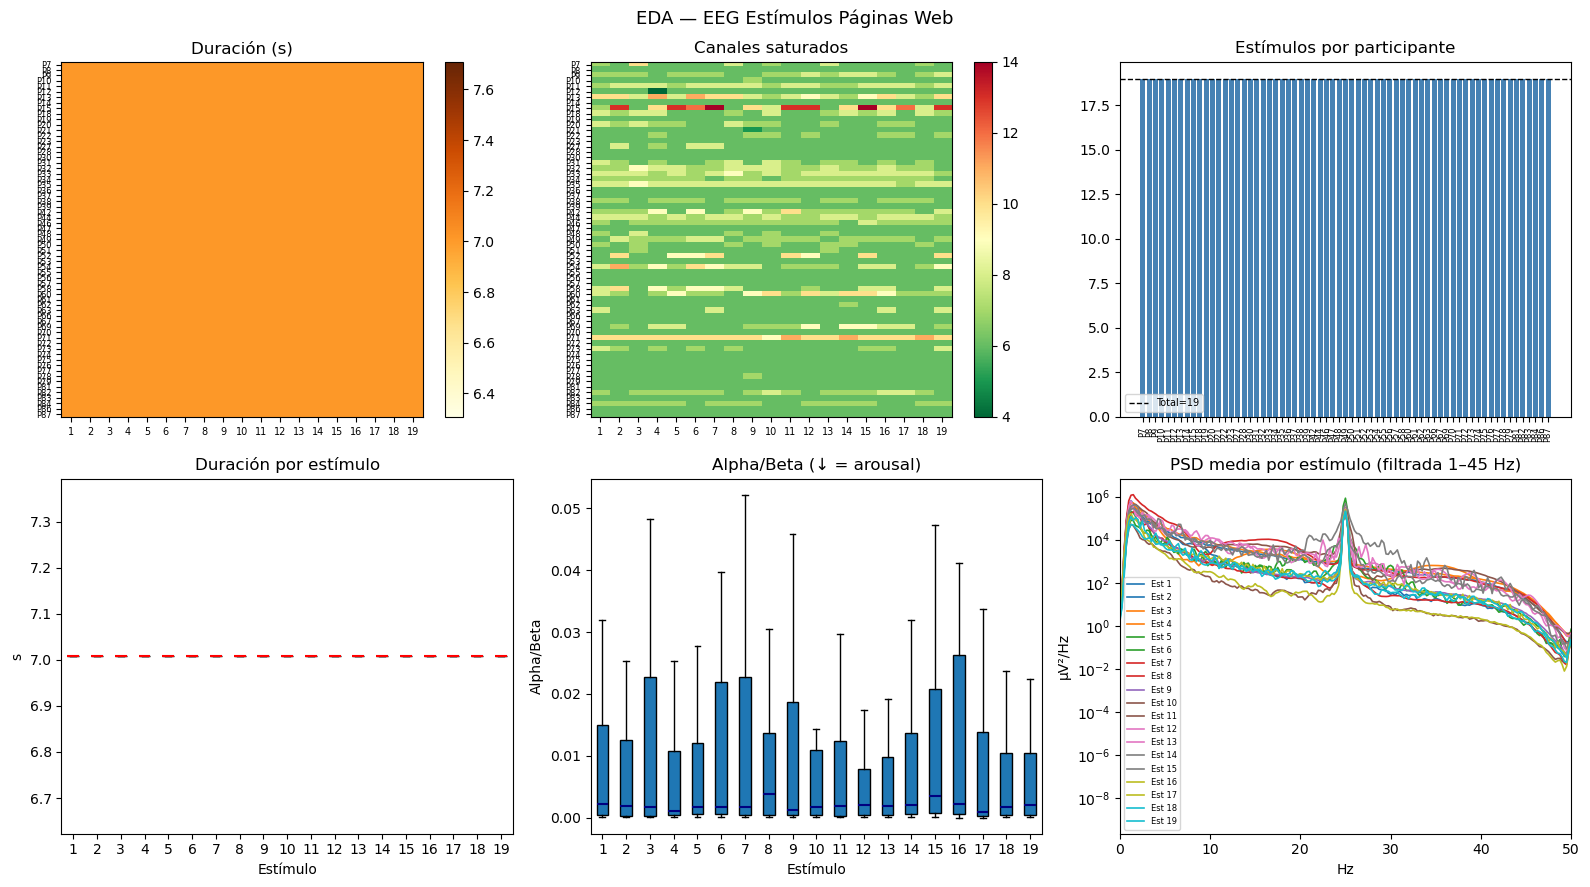

Guardado: eda_paginas_web.png


In [10]:
estims = sorted(meta["estimulo"].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Heatmap duración
ax = axes[0, 0]
piv = meta.pivot_table(index="participante", columns="estimulo", values="duracion_s")
im = ax.imshow(piv.values, aspect="auto", cmap="YlOrBr")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, fontsize=7)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels([f"P{p}" for p in piv.index], fontsize=6)
plt.colorbar(im, ax=ax); ax.set_title("Duración (s)")

# 2. Heatmap canales saturados
ax = axes[0, 1]
piv2 = meta.pivot_table(index="participante", columns="estimulo", values="n_sat_ch")
im2 = ax.imshow(piv2.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(piv2.columns))); ax.set_xticklabels(piv2.columns, fontsize=7)
ax.set_yticks(range(len(piv2.index)));   ax.set_yticklabels([f"P{p}" for p in piv2.index], fontsize=6)
plt.colorbar(im2, ax=ax); ax.set_title("Canales saturados")

# 3. Completitud
ax = axes[0, 2]
comp  = meta.groupby("participante")["estimulo"].nunique()
n_tot = len(estims)
ax.bar([f"P{p}" for p in comp.index], comp.values,
       color=["tomato" if v < n_tot else "steelblue" for v in comp.values])
ax.axhline(n_tot, color="k", ls="--", lw=1, label=f"Total={n_tot}")
ax.legend(fontsize=7); ax.set_title("Estímulos por participante")
ax.tick_params(axis="x", rotation=90, labelsize=6)

# 4. Boxplot duración por estímulo
ax = axes[1, 0]
data = [meta[meta["estimulo"] == e]["duracion_s"].values for e in estims]
ax.boxplot(data, labels=estims, showfliers=False, patch_artist=True,
           medianprops=dict(color="red", lw=1.5))
ax.set_xlabel("Estímulo"); ax.set_ylabel("s"); ax.set_title("Duración por estímulo")

# 5. Alpha/Beta ratio
ax = axes[1, 1]
band_df["a_b"] = band_df["Alpha"] / band_df["Beta"].replace(0, np.nan)
data_ab = [band_df[band_df["estimulo"] == e]["a_b"].dropna().values for e in estims]
ax.boxplot(data_ab, labels=estims, showfliers=False, patch_artist=True,
           medianprops=dict(color="navy", lw=1.5))
ax.set_xlabel("Estímulo"); ax.set_ylabel("Alpha/Beta"); ax.set_title("Alpha/Beta (↓ = arousal)")

# 6. PSD media por estímulo (sobre señal filtrada)
ax = axes[1, 2]
psd_by_e = {}
for r in res_ok:
    if r["freqs"]:
        psd_by_e.setdefault(r["estimulo"], []).append(np.array(r["psd"]))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(psd_by_e), 1)))
freqs_ref = np.array(next(r["freqs"] for r in res_ok if r["freqs"]))
for i, (e, psds) in enumerate(sorted(psd_by_e.items())):
    ax.semilogy(freqs_ref, np.mean(psds, axis=0), color=cmap[i % len(cmap)], lw=1.2, label=f"Est {e}")
ax.set_xlim(0, 50); ax.set_xlabel("Hz"); ax.set_ylabel("µV²/Hz")
ax.set_title("PSD media por estímulo (filtrada 1–45 Hz)"); ax.legend(fontsize=6)

plt.suptitle("EDA — EEG Estímulos Páginas Web", fontsize=13)
plt.tight_layout()
plt.savefig("eda_paginas_web.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: eda_paginas_web.png")

In [12]:
print(f"Participantes : {meta['participante'].nunique()}")
print(f"Estímulos     : {meta['estimulo'].nunique()} → {estims}")
print(f"Archivos OK   : {len(meta)}")
print(f"Duración media: {meta['duracion_s'].mean():.1f} s (±{meta['duracion_s'].std():.1f})")
print(f"Con saturación: {(meta['n_sat_ch'] > 0).sum()} archivos")
print()
print("Potencia mediana por banda:")
for b in BANDS:
    if b in band_df.columns:
        print(f"  {b:7s}: {band_df[b].median():.3e} µV²")

Participantes : 65
Estímulos     : 19 → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Archivos OK   : 1235
Duración media: 7.0 s (±0.0)
Con saturación: 1235 archivos

Potencia mediana por banda:
  Delta  : 1.842e+03 µV²
  Theta  : 1.638e+02 µV²
  Alpha  : 5.277e+01 µV²
  Beta   : 5.342e+04 µV²
  Gamma  : 2.129e+01 µV²


2026-07-05 05:00:07,619	WARNING dataclient.py:403 -- Encountered connection issues in the data channel. Attempting to reconnect.
2026-07-05 05:00:24,493	ERROR dataclient.py:330 -- Unrecoverable error in data channel.


NameError: name 'path_de_un_archivo' is not defined